In [1]:
# %load_ext autoreload
# %autoreload 2
import importlib
import logging

import numpy as np
import pandas as pd
from matplotlib.path import Path
import mphsweepkit.process_data as process_data
process_data = importlib.reload(process_data)
from mphsweepkit.meta_tex import *
from mphsweepkit.process_data import (
    DataPlot,
    PlotSettings,
    PlotTextOverrides,
    synchronize_axes,
)
import mphsweepkit.process_derive as derive

from dimensional_performance_factor.meta import paths

# Logging
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.WARNING)

# for scaling:
cm = 1 / 2.54

# rectangle marker for legend
a = 1.0
b = 2 * a
verts = np.array([
    [-a/2, -b/2],
    [ a/2, -b/2],
    [ a/2,  b/2],
    [-a/2,  b/2],
    [-a/2, -b/2],
])
rect_marker = Path(verts)

# Paths:
material_path = paths.material_data
simulation_path = paths.simulation_data
plot_path = paths.grafics
measurements_path = paths.measurement_data

In [2]:
dp = DataPlot.from_result_folder(simulation_path.joinpath("global_data"))
derive.convert_unit(dp.combined_df, "freq", "freq_kHz", "kHz", 1e-3, dtype="real")
# dp.combined_df

,cut_switch,matsw.comp1.sw1,b_mean,core_temperature,freq,geometry_idx,internal_idx,matsw.comp1.sw1_name,p (core),p (cut),p_el (cut),p_mag (cut),p (frame),p_el (frame),p_mag (frame),freq_kHz
name,,,,,,,,,,,,,,,,
unit,1,NaN,T,C,Hz,NaN,NaN,NaN,W,W,W,W,W,W,W,kHz
group,Geometry Sweep,Material Sweep,Excitation Sweep,Excitation Sweep,Frequency Sweep,Indexing,Indexing,Derived Metadata,post-processing,post-processing,post-processing,post-processing,post-processing,post-processing,post-processing,Derived
0,1.0,1.0,0.05,30.0,100000.0,0,0,N49 (LEA_MTB),0.33010706238458265,0.13646839663612995,0.003722772113848834,0.1327456245222809,0.19363866574845273,0.0026538626146540025,0.19098480313379865,100.0
1,1.0,1.0,0.05,30.0,200000.0,0,1,N49 (LEA_MTB),0.8747932698704115,0.36438784680407316,0.019445121052184218,0.34494272575188945,0.5104054230663385,0.013842452743501044,0.4965629703228365,200.0
2,1.0,1.0,0.05,30.0,300000.0,0,2,N49 (LEA_MTB),1.5679933582223993,0.6582421702876252,0.0528386171368289,0.6054035531507971,0.909751187934774,0.037531877772825885,0.872219310161949,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,2.0,2.0,0.05,90.0,900000.0,1,68,N49 static (LEA_MTB),10.613323995683185,4.2824021358707425,0.02968218485182196,4.25271995101891,6.330921859812443,0.060761825172420104,6.270160034640026,900.0
141,2.0,2.0,0.05,90.0,1000000.0,1,69,N49 static (LEA_MTB),13.857863143108347,5.592385041094672,0.036652962601663217,5.555732078493036,8.265478102013674,0.0750375258305106,8.190440576183171,1000.0
142,2.0,2.0,0.05,90.0,1100000.0,1,70,N49 static (LEA_MTB),18.029154465248425,7.276520690527474,0.044363430135272525,7.232157260392195,10.75263377472095,0.09083342695637076,10.661800347764569,1100.0


#### Simulation CYLINDER vs CUBOID

In [3]:
def plot_geometry_ratio(dp: DataPlot, ax, qty="p (core)"):
    
    custom_settings = PlotSettings(
        x_scale="linear",
        y_scale="linear",
        show_grid=True,
        grid_which="both",
        grid_alpha=0.5,
        marker_styles=(" ",),
        line_width=2.2,
        color_map_name="viridis",
        line_styles=("-", "--", "-.", ":"),
        show_color_legend=True,
        show_style_legend=True,
        use_tight_layout=True,
        show_title=False
    )

    dp.ratio_plot(
        ax,
        y_col=qty,
        x_col="freq_kHz",
        split_col="cut_switch",
        numerator_value="1.0",
        denominator_value="2.0",
        style_col="matsw.comp1.sw1_name",
        color_col="core_temperature",
        settings=custom_settings,
        text_overrides=PlotTextOverrides(
            x_label="Frequency",
            x_unit="kHz",
            y_label=r"$P_\mathrm{core,cylinder} / P_\mathrm{core,cuboid}$",
            y_unit="",
            color_label=r"$T_\mathrm{core}$",
            color_unit="C",
            style_label="material type",
            style_unit=" ",
    ),
)
plt.show()

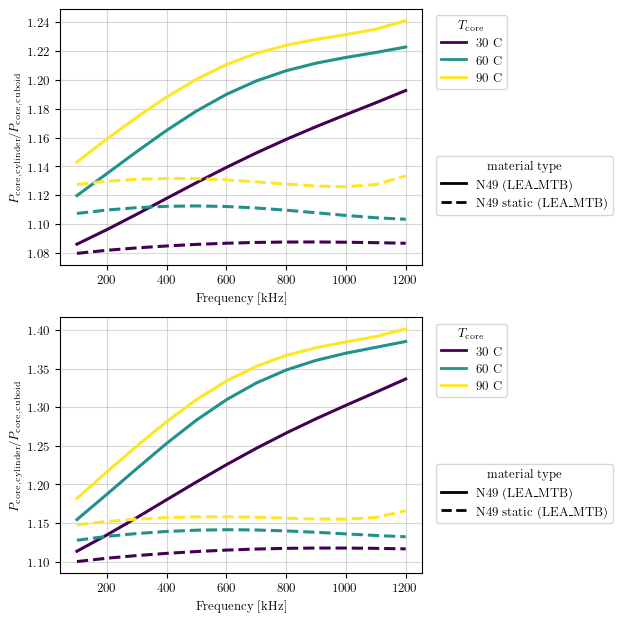

In [4]:
fig, ax = plt.subplots(2, figsize=(16*cm, 16*cm))
plot_geometry_ratio(dp, ax[0], qty="p (core)")
plot_geometry_ratio(dp, ax[1], qty="p (cut)")
# plot_geometry_ratio(dp, ax[1], qty="p_el (cut)")

#### Comparison with the measurements

Select the material model to be used:

In [5]:
dp_mat = dp.filter_rows(
    {"matsw.comp1.sw1_name": ["N49 static (LEA_MTB)"]}
)
dp_dyn = dp.filter_rows(
     {"matsw.comp1.sw1_name": ["N49 (LEA_MTB)"]}
)

In [6]:
def plot_geometry_comparison(dp: DataPlot, ax, qty="p (core)"):
    
    custom_settings = PlotSettings(
        x_scale="linear",
        y_scale="linear",
        show_grid=True,
        grid_which="both",
        grid_alpha=0.5,
        marker_styles=(" ",),
        line_width=2.2,
        color_map_name="viridis",
        line_styles=("-", "--", "-.", ":"),
        show_color_legend=True,
        show_style_legend=True,
        use_tight_layout=True,
        show_title=False
    )

    dp.y_over_x_with_color_and_style(
        ax,
        y_col=qty,
        x_col="freq_kHz",
        color_col="core_temperature",
        style_col="cut_switch",
        settings=custom_settings,
        text_overrides=PlotTextOverrides(
            x_label="Frequency",
            x_unit="kHz",
            y_label=qty,
            y_unit=r"W",
            color_label=r"$T_\mathrm{core}$",
            color_unit="C",
            style_label="Cyl vs Cuboid",
            style_unit=" "
        )
    )

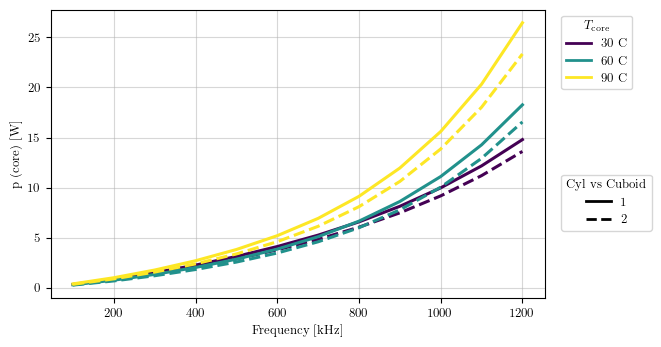

In [7]:
fig, ax = plt.subplots(figsize=(17 / 2.54, 9 / 2.54))
plot_geometry_comparison(dp=dp_mat, ax=ax, qty="p (core)")

#### Simulation vs Measurements

Load the measurements and add overall losses

In [8]:
df_meas = pd.read_csv(measurements_path.joinpath("fd_results.csv"), sep=",", decimal=".", index_col=None)
df_meas["f_kHz"] = df_meas["f"] / 1000
df_meas["p_total"] = df_meas["volume"] * df_meas["p_density_hyst"]
# df_meas

Filter the simulaion data

In [9]:
material_select = "N49 (LEA_MTB)"

In [10]:
dp = DataPlot.from_result_folder(simulation_path.joinpath("global_data"))

# Process the data once and keep dp as the unfiltered source.
derive.convert_unit(dp.combined_df, "freq", "freq_kHz", "kHz", 1e-3, dtype="real")
dp_mat = dp.filter_rows(
    {"matsw.comp1.sw1_name": [material_select]}
)

temperatures = ("30.0", "60.0", "90.0")
dp_by_temperature = {
    temperature: dp_mat.filter_rows({"core_temperature": [temperature]})
    for temperature in temperatures
}

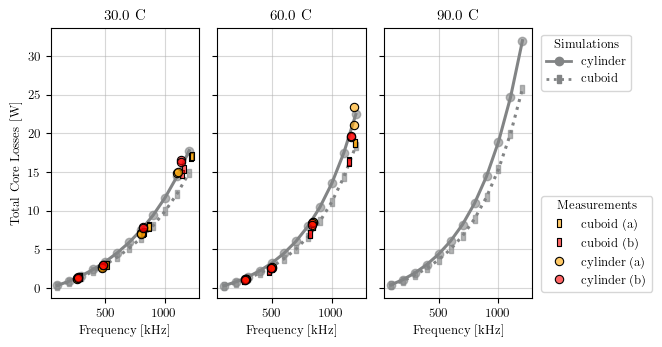

In [11]:
def plot_simulation_vs_measurements(
    simulations_by_temperature,
    measurements_by_temperature,
    measurement_df,
    output_path,
    rect_marker,
    qty="p (core)",
    output_name="simulation_vs_measurements.pdf",
    share_x=True,
    share_y=True,
    shared_legends=True,
):
    temperatures = tuple(simulations_by_temperature)
    if set(temperatures) != set(measurements_by_temperature):
        raise ValueError("Simulation and measurement temperatures must match.")

    simulations_color = "#828485"
    color_map = {
        value: simulations_color
        for temperature in temperatures
        for value in (temperature, float(temperature))
    }
    style_value_labels = {
        value: label
        for values, label in (
            ((1, 1.0, "1", "1.0"), "cylinder"),
            ((2, 2.0, "2", "2.0"), "cuboid"),
        )
        for value in values
    }

    settings = PlotSettings(
        x_scale="linear",
        y_scale="linear",
        show_grid=True,
        grid_which="both",
        grid_alpha=0.5,
        marker_styles=("o", rect_marker),
        line_width=2.2,
        line_alpha=1,
        marker_alpha=0.6,
        color_map=color_map,
        line_styles=("-", ":"),
        show_color_legend=False,
        show_style_legend=True,
        style_legend_anchor=(1.02, 1.0),
        style_legend_color=simulations_color,
        style_value_labels=style_value_labels,
        use_tight_layout=False,
        show_title=False,
    )
    text_overrides = PlotTextOverrides(
        x_label="Frequency",
        x_unit="kHz",
        y_label="Total Core Losses",
        y_unit="W",
        color_label=r"$T_\mathrm{core}$",
        color_unit="C",
        style_label="Simulations",
        style_unit=" ",
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(temperatures),
        figsize=(17 / 2.54, 9 / 2.54),
        sharex=share_x,
        sharey=share_y,
        squeeze=False,
    )
    axes = axes[0]
    legend_index = len(axes) - 1

    for index, (ax, temperature) in enumerate(zip(axes, temperatures)):
        show_legends = not shared_legends or index == legend_index
        simulations_by_temperature[temperature].measurement_vs_simulation(
            ax=ax,
            measurement_df=measurement_df,
            measurement_groups=measurements_by_temperature[temperature],
            y_col=qty,
            x_col="freq_kHz",
            color_col="core_temperature",
            style_col="cut_switch",
            measurement_x_col="f_kHz",
            measurement_y_col="p_total",
            measurement_range_offset=-2,
            settings=settings,
            text_overrides=text_overrides,
            measurement_legend_title="Measurements",
            measurement_legend_anchor=(1.02, 0.0),
            measurement_line_alpha=0.6,
            measurement_marker_alpha=0.6,
            show_simulation_color_legend=False,
            show_simulation_style_legend=show_legends,
            show_measurement_legend=show_legends,
            show_x_label=True,
            show_y_label=index == 0,
        )
        ax.set_title(f"{temperature} C")

    synchronize_axes(axes, share_x=share_x, share_y=share_y)
    fig.tight_layout()
    fig.savefig(output_path.joinpath(output_name), bbox_inches="tight")
    plt.show()


measurement_styles = {
    "cuboid (a)": {"linestyle": " ", "markerstyle": rect_marker, "color": "orange"},
    "cuboid (b)": {"linestyle": " ", "markerstyle": rect_marker, "color": "red"},
    "cylinder (a)": {"linestyle": " ", "markerstyle": "o", "color": "orange"},
    "cylinder (b)": {"linestyle": " ", "markerstyle": "o", "color": "red"},
}
measurement_ranges = {
    "30.0": {
        "cuboid (a)": [(6, 9), (10, 13)],
        "cuboid (b)": [(2, 5), (30, 33)],
        "cylinder (a)": [(14, 17), (18, 21)],
        "cylinder (b)": [(22, 25), (26, 29)],
    },
    "60.0": {
        "cuboid (a)": [(42, 45), (46, 49)],
        "cuboid (b)": [(34, 37), (38, 41)],
        "cylinder (a)": [(50, 53), (54, 57)],
        "cylinder (b)": [(58, 61), (62, 65)],
    },
    "90.0": {name: [] for name in measurement_styles},
}
measurements_by_temperature = {
    temperature: {
        name: {**measurement_styles[name], "ranges": ranges}
        for name, ranges in measurement_ranges[temperature].items()
    }
    for temperature in temperatures
}

plot_simulation_vs_measurements(
    simulations_by_temperature=dp_by_temperature,
    measurements_by_temperature=measurements_by_temperature,
    measurement_df=df_meas,
    output_path=plot_path,
    rect_marker=rect_marker,
    qty="p (core)",
    output_name=f"simulation_vs_measurements__{material_select.replace(' ', '_')}.pdf",
)